<a href="https://www.kaggle.com/code/hideos/minimal-ml-ops-project-daily-usd-jpy-processing?scriptVersionId=296078569" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Summary

- **Purpose**  
  Demonstrates capabilities by visualizing USD/JPY rate changes and showing an end‑to‑end data workflow.

- **Automation**  
  Automate data updates to GitHub: use a scheduled GitHub Actions workflow to call the API, transform data, update data files, and commit updated data to the repository.  
  Automate notebook refresh: keep the Kaggle notebook graph current by scheduling the notebook to run and pull the latest raw file from GitHub

- **Documentation sync**  
  Embed the repository README into the notebook so documentation is maintained in one place and rendered live in Kaggle.

- **Benefits**  
  **Reproducibility and reliability:** automated, versioned data and CI reduce manual errors and ensure the notebook reflects the canonical dataset.  
  **Maintainability:** a single source (GitHub) for code and docs eliminates duplication and simplifies collaboration.  
  **Visibility and control:** CI logs, commit history, and scheduled runs provide operational transparency.

# Graph of USD/JPY

<Axes: xlabel='date'>

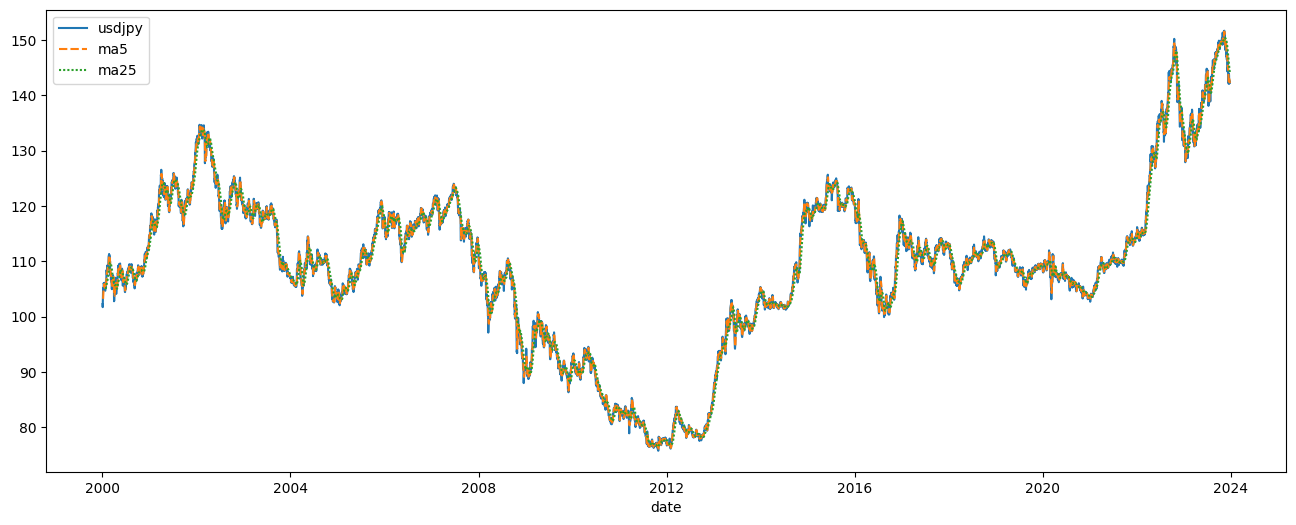

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
GITHUB_BASE="https://raw.githubusercontent.com"
GITHUB_OWNER="hide-san"
GITHUB_REPO="usdjpy-mlops"
GITHUB_BASE_URL=f"{GITHUB_BASE}/{GITHUB_OWNER}/{GITHUB_REPO}"

df_usdjpy = pd.read_csv('/kaggle/input/daily-usdjpy-dataset/usdjpy.csv', parse_dates=["date"], index_col="date")
df_usdjpy = df_usdjpy[["usdjpy", "ma5", "ma25"]]

plt.figure(figsize=(16,6))
sns.lineplot(data=df_usdjpy)

# Analysis of lag

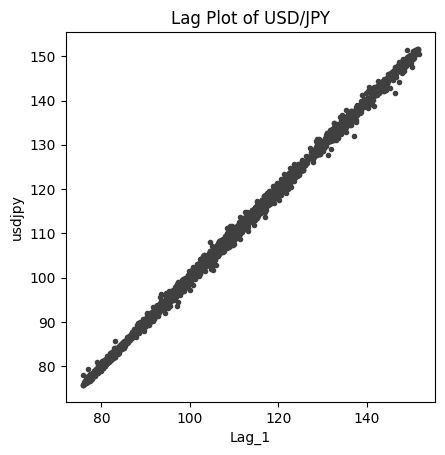

In [2]:
df_usdjpy['Lag_1'] = df_usdjpy['usdjpy'].shift(1)

X = df_usdjpy.loc[:, ['Lag_1']]
X.dropna(inplace=True)  # drop missing values in the feature set
y = df_usdjpy.loc[:, 'usdjpy']  # create the target
y, X = y.align(X, join='inner')  # drop corresponding values in target

fig, ax = plt.subplots()
ax.plot(X['Lag_1'], y, '.', color='0.25')
ax.set_aspect('equal')
ax.set_ylabel('usdjpy')
ax.set_xlabel('Lag_1')
ax.set_title('Lag Plot of USD/JPY');

# Details
The below are the details of this implementation, pulled from GitHub.

In [3]:
import requests
from IPython.display import Markdown, display

url_readme = f"{GITHUB_BASE_URL}/main/README.md"

github_readme = requests.get(url_readme)
github_readme.raise_for_status()
display(Markdown(github_readme.text))

# Minimal ML Ops Project: Automatically Collecting and Processing Daily USD/JPY Data
This project implements a minimal yet practical ML Ops pipeline that automatically collects, processes, and analyzes daily USD/JPY exchange rate data. It demonstrates the core components of ML Ops — data ingestion, preprocessing, analysis, automation, and reproducibility — using lightweight tools such as Python and GitHub Actions.

# Project Overview
The goal is to build a fully automated data pipeline that:
* Fetches the latest USD/JPY exchange rate from a public API
* Stores the data in a structured format
* Performs preprocessing and computes financial indicators
* Runs simple analysis such as trend detection or volatility checks
* Executes automatically every day via GitHub Actions
* Produces clean data that can be visualized later (e.g., in a Kaggle Notebook)
This project is intentionally minimal, focusing on reliability and automation rather than complex modeling.

---
# Pipeline Architecture
```
GitHub Actions (daily scheduled run)
        ↓
fetch.py      – Collect USD/JPY data from a public API
process.py    – Clean and preprocess the data
analyze.py    – Compute indicators and simple signals
        ↓
data/usdjpy.csv – Persist processed data
        ↓
Visualization (Note this can be implemnted exernally. e.g. Kaggle Notebook)
```

---
# Project Structure
```
usdjpy-mlops/
├── fetch.py          # Data ingestion
├── process.py        # Preprocessing and feature engineering
├── analyze.py        # Lightweight analysis logic
├── data/
│   └── usdjpy.csv    # Persisted dataset
├── .github/
│   └── workflows/
│       └── pipeline.yml   # GitHub Actions automation
└── README.md
```

---
# Components
## **1. Data Ingestion (`fetch.py`)**
- Retrieves the latest USD/JPY exchange rate  
- Normalizes date and rate fields  
- Appends to `data/usdjpy.csv`  
- Ensures idempotency (safe re-runs)  
- Logs success/failure  

## **2. Preprocessing (`process.py`)**
- Sorts data by date  
- Calculates:
  - 5-day moving average (MA5)  
  - 25-day moving average (MA25)  
  - Daily percentage change  
- Handles duplicates and missing values  

## **3. Analysis (`analyze.py`)**
Applies simple, interpretable financial logic:

- Spike detection (e.g., ±1% daily move)  
- Trend detection (MA5 vs MA25 crossover)  
- Volatility checks  

---
# Automation with GitHub Actions
The pipeline runs automatically every day using a scheduled workflow:
```
yaml
on:
  schedule:
    - cron: "0 9 * * *"   # Runs daily at 09:00 UTC
  workflow_dispatch:       # Allows manual execution
```

---
# External Links
- **ExchangeRate Host (API)** — https://exchangerate.host  
  Public foreign exchange rates API used for fetching USD/JPY. Check usage limits and terms before commercial use. **Last checked: 2026-01-19.**
- **Kaggle Notebook** — https://www.kaggle.com/code/hideos/minimal-ml-ops-project-daily-usd-jpy-processing  
  Interactive notebook for visualization and exploration of the collected USD/JPY data.
- **GitHub Repository** — https://github.com/hide-san/usdjpy-mlops/  
  Public repository containing the automated daily USD/JPY data pipeline.
> **Note:** This repository does not contain any API keys. API keys (if required) are stored securely in GitHub Actions Secrets and are never committed to the repo.

